# Pneumonia Detection from Chest X-Ray Images Using Deep Learning

**Project type:** Deep Learning / Medical Image Classification  
**Models:** Baseline CNN, ResNet50 (transfer learning + fine-tuning), EfficientNetB0 (transfer learning + fine-tuning), and Vision Transformer (ViT)  
**Dataset:** Kaggle Chest X-Ray Pneumonia dataset

## Project Overview
This notebook develops and compares four deep learning approaches for classifying chest X-ray images into **NORMAL** and **PNEUMONIA** classes.

The workflow includes:
- dataset loading and preprocessing,
- data augmentation and class weighting,
- baseline CNN training,
- transfer learning and fine-tuning with ResNet50 and EfficientNetB0,
- a Vision Transformer trained from scratch,
- evaluation with Accuracy, Precision, Recall, Specificity, F1-score, AUC, and confusion matrices,
- final model comparison and sample predictions.

> **Disclaimer:** This project is for educational and research purposes only. It is **not intended for clinical diagnosis or medical decision-making**.

## 1. Environment and Project Paths

In [32]:
# Proje yollarını tanımlıyoruz
from pathlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

project_dir = Path.cwd()

base_dir = project_dir / "dataset" / "chest_xray"
train_dir = base_dir / "train"
test_dir = base_dir / "test"
val_dir = base_dir / "val"

models_dir = project_dir / "models"
results_dir = project_dir / "results"

models_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print("Project folder:", project_dir)
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())
print("Models exists:", models_dir.exists())
print("Results exists:", results_dir.exists())

Project folder: /Users/ahmedazaz/Desktop/deep learing project 
Train exists: True
Test exists: True
Models exists: True
Results exists: True


In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

## 2. Dataset Loading and Preprocessing

In [36]:
img_size = (224, 224)
batch_size = 32
seed = 42

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [77]:
# Daha hafif data augmentation

# Amaç: X-ray görüntülerini fazla bozmadan modeli daha dayanıklı hale getirmek
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.03, 0.03)
], name="data_augmentation")

In [38]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

In [39]:

from sklearn.utils.class_weight import compute_class_weight

normal_count = len(list((train_dir / "NORMAL").glob("*")))
pneumonia_count = len(list((train_dir / "PNEUMONIA").glob("*")))

y_train_approx = np.array([0] * normal_count + [1] * pneumonia_count)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train_approx
)

class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

print("NORMAL count:", normal_count, "| PNEUMONIA count:", pneumonia_count)
print("Class weights:", class_weight_dict)

NORMAL count: 1341 | PNEUMONIA count: 3875
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


## 3. Baseline CNN

In [40]:
# Baseline CNN modelini oluşturuyoruz
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [42]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "baseline_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [43]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.3159 - auc: 0.5347 - loss: 0.7021 - precision: 0.7420 - recall: 0.0943 - val_accuracy: 0.2387 - val_auc: 0.7154 - val_loss: 0.7667 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.3125 - auc: 0.6129 - loss: 0.6963 - precision: 0.8356 - recall: 0.0646 - val_accuracy: 0.5005 - val_auc: 0.8245 - val_loss: 0.6968 - val_precision: 0.9964 - val_recall: 0.3451 - learning_rate: 1.0000e-04
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.5107 - auc: 0.7753 - loss: 0.6606 - precision: 0.9627 - recall: 0.3448 - val_accuracy: 0.7670 - val_auc: 0.8208 - val_loss: 0.5584 - val_precision: 0.8555 - val_recall: 0.8350 - learning_rate: 1.0000e-04
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.7308 - auc: 0.8395 - loss: 0.5636 - precision: 0.9365 - recall: 0.6782 - val_accuracy: 0.7814 - val_auc: 0.

In [44]:
test_results = model.evaluate(test_data)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])
print("Test AUC:", test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6138 - auc: 0.6012 - loss: 0.9117 - precision: 0.3804 - recall: 0.6351
Test Loss: 0.5467520952224731
Test Accuracy: 0.7740384340286255
Test Precision: 0.7475149035453796
Test Recall: 0.964102566242218
Test AUC: 0.8997808694839478


In [45]:
# F1-score hesaplama
precision = test_results[2]
recall = test_results[3]

f1 = 2 * (precision * recall) / (precision + recall)

print("Test F1-score:", f1)
print("Test F1-score (%):", f1 * 100)

Test F1-score: 0.8421052595377367
Test F1-score (%): 84.21052595377367


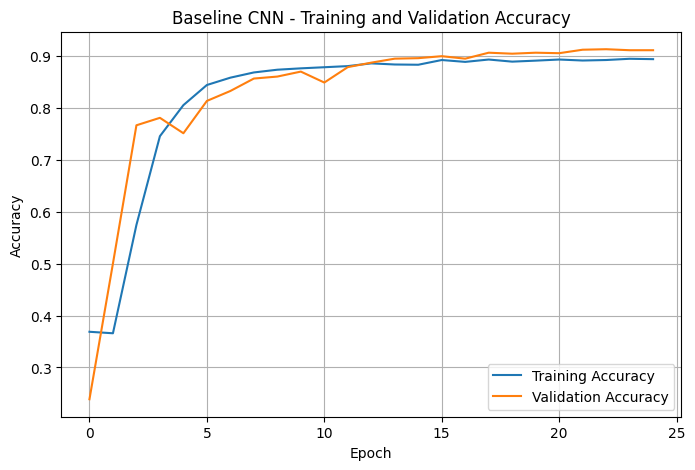

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(results_dir / "baseline_cnn_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

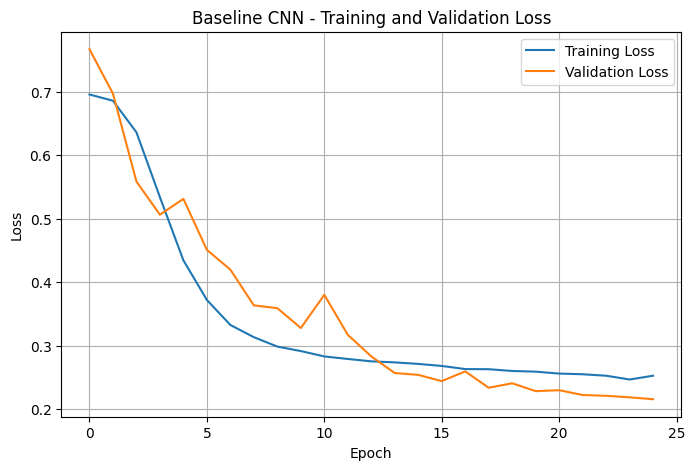

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(results_dir / "baseline_cnn_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
# Modeli test verisi üzerinde değerlendiriyoruz
test_results = model.evaluate(test_data)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])
print("Test AUC:", test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6138 - auc: 0.6012 - loss: 0.9117 - precision: 0.3804 - recall: 0.6351
Test Loss: 0.5467520952224731
Test Accuracy: 0.7740384340286255
Test Precision: 0.7475149035453796
Test Recall: 0.964102566242218
Test AUC: 0.8997808694839478


 3/20 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 

2026-07-10 18:42:54.795649: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


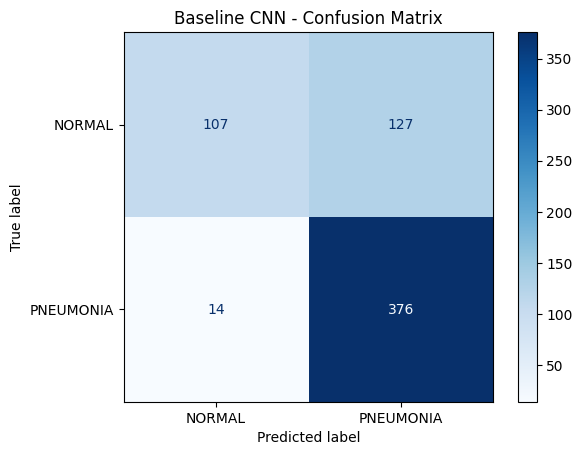

              precision    recall  f1-score   support

      NORMAL       0.88      0.46      0.60       234
   PNEUMONIA       0.75      0.96      0.84       390

    accuracy                           0.77       624
   macro avg       0.82      0.71      0.72       624
weighted avg       0.80      0.77      0.75       624



In [49]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Test verisindeki gerçek etiketleri alıyoruz
y_true = np.concatenate([y for x, y in test_data], axis=0)

# Modelin test verisi üzerindeki tahmin olasılıklarını alıyoruz
y_prob = model.predict(test_data)

# Olasılıkları sınıf etiketine çeviriyoruz
# 0 = NORMAL
# 1 = PNEUMONIA
y_pred = (y_prob > 0.5).astype("int32").reshape(-1)

# Confusion matrix oluşturuyoruz
cm = confusion_matrix(y_true, y_pred)

# Confusion matrix'i görselleştiriyoruz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline CNN - Confusion Matrix")

# Görseli results klasörüne kaydediyoruz
plt.savefig(results_dir / "baseline_cnn_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Precision, Recall ve F1-score değerlerini yazdırıyoruz
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [50]:
# Confusion matrix değerlerini alıyoruz
tn, fp, fn, tp = cm.ravel()

# Temel metrikleri hesaplıyoruz
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1-score:", f1_score)

Accuracy: 0.7740384615384616
Precision: 0.7475149105367793
Recall: 0.9641025641025641
Specificity: 0.45726495726495725
F1-score: 0.8421052631578948


### Baseline CNN — Interpretation
The Baseline CNN provides the reference point for the project. Its evaluation above shows how a model trained from scratch performs before transfer learning is introduced. The final comparison section computes all summary metrics directly from the current run to avoid stale hard-coded values.

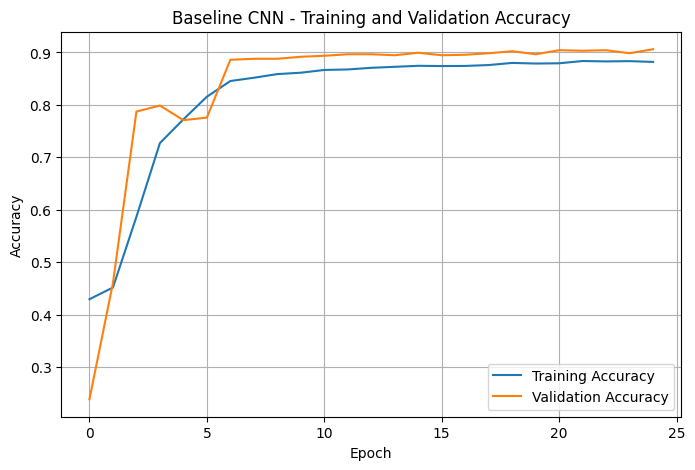

In [17]:
# Eğitim ve doğrulama accuracy grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

# Grafiği results klasörüne kaydediyoruz
plt.savefig(results_dir / "baseline_cnn_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

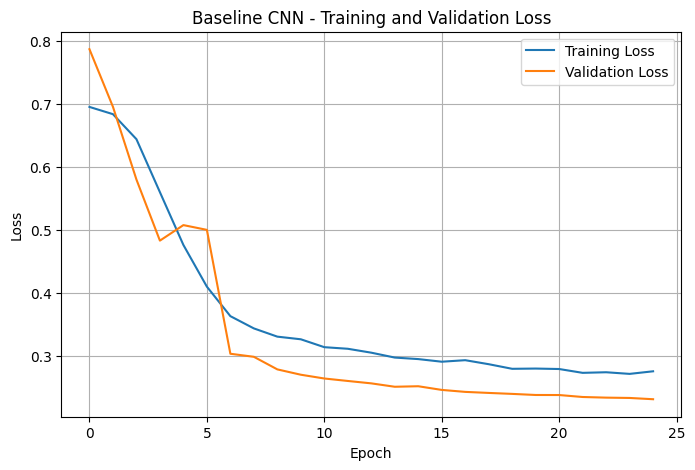

In [18]:
# Eğitim ve doğrulama loss grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training and Validation Loss")

plt.legend()
plt.grid(True)

# Grafiği results klasörüne kaydediyoruz
plt.savefig(results_dir / "baseline_cnn_loss.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
# Eğitilen modeli models klasörüne kaydediyoruz
model.save(models_dir / "baseline_cnn_final.keras")

Baseline CNN modeli test verisi üzerinde %77.40 accuracy, %74.75 precision, %96.41 recall, %84.21 F1-score ve %89.98 AUC değerlerine ulaşmıştır. Confusion matrix sonuçlarına göre model 390 pnömoni görüntüsünden 376 tanesini doğru sınıflandırmış, yalnızca 14 pnömoni görüntüsünü normal olarak tahmin etmiştir. Bu durum modelin pnömoni vakalarını yakalamada başarılı olduğunu göstermektedir. Ancak 234 normal görüntünün 127 tanesi yanlışlıkla pnömoni olarak sınıflandırılmıştır. Bu nedenle modelin recall değeri yüksek olmasına rağmen normal sınıfını ayırt etme başarısı sınırlı kalmıştır.

## 4. ResNet50 — Transfer Learning and Fine-Tuning

In [51]:
# ResNet50 modeli için gerekli katmanları hazırlıyoruz
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Önceden eğitilmiş ResNet50 modelini yüklüyoruz
base_model_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# İlk aşamada ResNet50 katmanlarını donduruyoruz
base_model_resnet.trainable = False

# Data augmentation katmanları
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

# ResNet50 tabanlı modeli oluşturuyoruz
resnet_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Lambda(preprocess_input),

    base_model_resnet,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

resnet_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [53]:
# ResNet50 modelini eğitim için hazırlıyoruz
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [54]:
# Eğitim sırasında en iyi modeli kaydetmek ve erken durdurma yapmak için callback tanımlıyoruz
resnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "resnet50_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [55]:
# ResNet50 modelini eğitiyoruz (Aşama 1: base_model dondurulmuş)
resnet_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=resnet_callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 320ms/step - accuracy: 0.6519 - auc: 0.7207 - loss: 0.7399 - precision: 0.8321 - recall: 0.6470 - val_accuracy: 0.9300 - val_auc: 0.9812 - val_loss: 0.1843 - val_precision: 0.9839 - val_recall: 0.9232 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 306ms/step - accuracy: 0.8973 - auc: 0.9630 - loss: 0.2536 - precision: 0.9582 - recall: 0.8985 - val_accuracy: 0.9425 - val_auc: 0.9857 - val_loss: 0.1569 - val_precision: 0.9842 - val_recall: 0.9395 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 312ms/step - accuracy: 0.9162 - auc: 0.9737 - loss: 0.2128 - precision: 0.9674 - recall: 0.9162 - val_accuracy: 0.9482 - val_auc: 0.9883 - val_loss: 0.1485 - val_precision: 0.9868 - val_recall: 0.9446 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9347 - auc: 0.9801 - loss: 0.1869 - precision: 0.9719 - recall: 0.9378 - val_accuracy: 0.9348 - val_auc: 0.9894 

In [56]:
# ResNet50 modelini test verisi üzerinde değerlendiriyoruz
resnet_test_results = resnet_model.evaluate(test_data)

print("ResNet50 Test Loss:", resnet_test_results[0])
print("ResNet50 Test Accuracy:", resnet_test_results[1])
print("ResNet50 Test Precision:", resnet_test_results[2])
print("ResNet50 Test Recall:", resnet_test_results[3])
print("ResNet50 Test AUC:", resnet_test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.7997 - auc: 0.6353 - loss: 0.5980 - precision: 0.4564 - recall: 0.6462
ResNet50 Test Loss: 0.3947785496711731
ResNet50 Test Accuracy: 0.8653846383094788
ResNet50 Test Precision: 0.8384955525398254
ResNet50 Test Recall: 0.971794843673706
ResNet50 Test AUC: 0.9532380104064941


#### ResNet50 - Fine-Tuning Aşaması
İlk aşamada yalnızca eklenen Dense katmanları eğitildi (base_model dondurulmuş). Şimdi ResNet50'nin son 30 katmanını açıp çok küçük bir öğrenme oranıyla (1e-5) devam ediyoruz; bu, ImageNet ağırlıklarının göğüs röntgeni özelliklerine ince ayar yapmasını sağlar.

In [57]:
# ============================================================
# Aşama 2: Fine-Tuning - ResNet50'nin üst katmanlarını açıyoruz
# ============================================================
base_model_resnet.trainable = True

# Yalnızca son 30 katmanı eğitilebilir yapıyoruz, geri kalanı dondurulmuş kalır
fine_tune_at = len(base_model_resnet.layers) - 30
for layer in base_model_resnet.layers[:fine_tune_at]:
    layer.trainable = False

# Çok daha düşük bir öğrenme oranıyla yeniden derliyoruz (ImageNet ağırlıklarını bozmamak için)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

resnet_finetune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "resnet50_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

resnet_finetune_history = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=resnet_finetune_callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 419ms/step - accuracy: 0.9449 - auc: 0.9871 - loss: 0.1426 - precision: 0.9871 - recall: 0.9368 - val_accuracy: 0.9511 - val_auc: 0.9948 - val_loss: 0.1525 - val_precision: 0.9973 - val_recall: 0.9383 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 425ms/step - accuracy: 0.9654 - auc: 0.9941 - loss: 0.0872 - precision: 0.9918 - recall: 0.9607 - val_accuracy: 0.9540 - val_auc: 0.9953 - val_loss: 0.1343 - val_precision: 0.9960 - val_recall: 0.9433 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 529ms/step - accuracy: 0.9755 - auc: 0.9972 - loss: 0.0651 - precision: 0.9963 - recall: 0.9702 - val_accuracy: 0.9636 - val_auc: 0.9958 - val_loss: 0.1161 - val_precision: 0.9974 - val_recall: 0.9547 - learning_rate: 1.0000e-05
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 531ms/step - accuracy: 0.9780 - auc: 0.9963 - loss: 0.0643 - precision: 0.9947 - recall: 0.9751 - val_accuracy: 0.9569 - val_auc: 0.9942 

In [58]:
# Fine-tuning sonrası ResNet50'yi test verisi üzerinde yeniden değerlendiriyoruz
resnet_test_results = resnet_model.evaluate(test_data)

print("ResNet50 (Fine-tuned) Test Loss:", resnet_test_results[0])
print("ResNet50 (Fine-tuned) Test Accuracy:", resnet_test_results[1])
print("ResNet50 (Fine-tuned) Test Precision:", resnet_test_results[2])
print("ResNet50 (Fine-tuned) Test Recall:", resnet_test_results[3])
print("ResNet50 (Fine-tuned) Test AUC:", resnet_test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.8242 - auc: 0.6327 - loss: 0.6167 - precision: 0.4695 - recall: 0.6504
ResNet50 (Fine-tuned) Test Loss: 0.4117920696735382
ResNet50 (Fine-tuned) Test Accuracy: 0.879807710647583
ResNet50 (Fine-tuned) Test Precision: 0.8523489832878113
ResNet50 (Fine-tuned) Test Recall: 0.9769230484962463
ResNet50 (Fine-tuned) Test AUC: 0.947413980960846


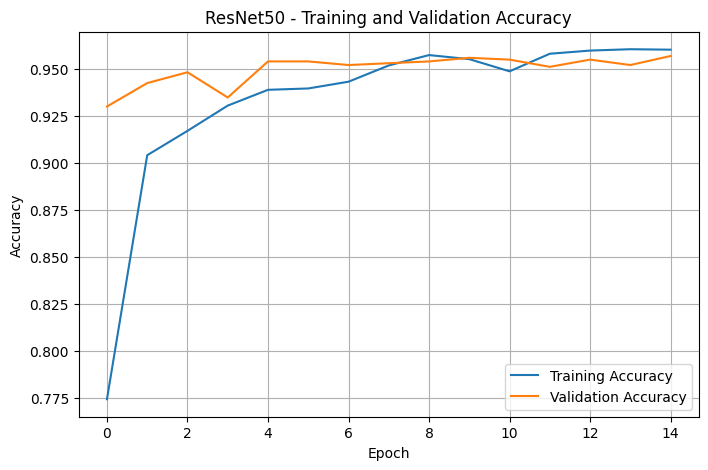

In [59]:
# ResNet50 için eğitim ve doğrulama accuracy grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(resnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

# Grafiği results klasörüne kaydediyoruz
plt.savefig(results_dir / "resnet50_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

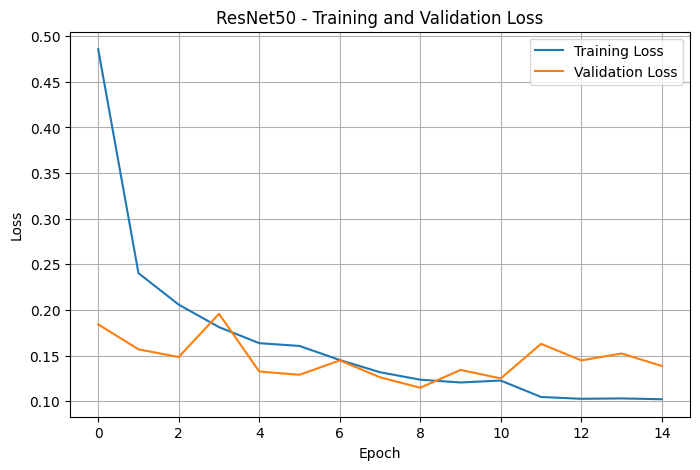

In [60]:
# ResNet50 için eğitim ve doğrulama loss grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(resnet_history.history["loss"], label="Training Loss")
plt.plot(resnet_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Training and Validation Loss")

plt.legend()
plt.grid(True)

# Grafiği results klasörüne kaydediyoruz
plt.savefig(results_dir / "resnet50_loss.png", dpi=300, bbox_inches="tight")

plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step


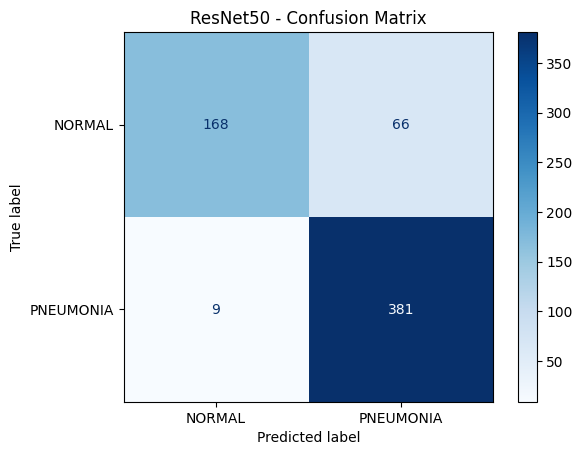

              precision    recall  f1-score   support

      NORMAL       0.95      0.72      0.82       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.86       624
weighted avg       0.89      0.88      0.88       624



In [61]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Test verisindeki gerçek etiketleri alıyoruz
y_true = np.concatenate([y for x, y in test_data], axis=0)

# ResNet50 modelinin tahmin olasılıklarını alıyoruz
y_prob_resnet = resnet_model.predict(test_data)

# Olasılıkları 0 veya 1 sınıfına çeviriyoruz
# 0 = NORMAL
# 1 = PNEUMONIA
y_pred_resnet = (y_prob_resnet > 0.5).astype("int32").reshape(-1)

# Confusion matrix oluşturuyoruz
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

# Confusion matrix'i görselleştiriyoruz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("ResNet50 - Confusion Matrix")

# Görseli results klasörüne kaydediyoruz
plt.savefig(results_dir / "resnet50_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Classification report yazdırıyoruz
print(classification_report(
    y_true,
    y_pred_resnet,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [62]:
# Eğitilen ResNet50 modelini models klasörüne kaydediyoruz
resnet_model.save(models_dir / "resnet50_final.keras")

### ResNet50 — Interpretation
ResNet50 uses ImageNet transfer learning followed by fine-tuning of the upper layers with a smaller learning rate. This approach is intended to adapt pretrained visual features to chest X-ray classification while preserving useful pretrained representations.

## 5. EfficientNetB0 — Transfer Learning and Fine-Tuning

In [78]:
# EfficientNetB0 modeli için gerekli katmanları hazırlıyoruz
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Önceden eğitilmiş EfficientNetB0 modelini yüklüyoruz
base_model_effnet = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# İlk aşamada EfficientNetB0 katmanlarını donduruyoruz
base_model_effnet.trainable = False

# Data augmentation katmanları
effnet_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

# EfficientNetB0 tabanlı modeli oluşturuyoruz
effnet_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
      data_augmentation,

   

    tf.keras.layers.Lambda(preprocess_input),

    base_model_effnet,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

effnet_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [79]:
# EfficientNetB0 modelini eğitim için hazırlıyoruz
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [80]:
# Eğitim sırasında en iyi modeli kaydetmek ve erken durdurma yapmak için callback tanımlıyoruz
effnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "efficientnetb0_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [81]:
# EfficientNetB0 modelini eğitiyoruz (Aşama 1: base_model dondurulmuş)
effnet_history = effnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=effnet_callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 333ms/step - accuracy: 0.7012 - auc: 0.7415 - loss: 0.6198 - precision: 0.8440 - recall: 0.7305 - val_accuracy: 0.8313 - val_auc: 0.9652 - val_loss: 0.3592 - val_precision: 0.9874 - val_recall: 0.7884 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 217ms/step - accuracy: 0.8646 - auc: 0.9452 - loss: 0.3061 - precision: 0.9540 - recall: 0.8556 - val_accuracy: 0.8715 - val_auc: 0.9746 - val_loss: 0.2901 - val_precision: 0.9896 - val_recall: 0.8401 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 223ms/step - accuracy: 0.9032 - auc: 0.9688 - loss: 0.2331 - precision: 0.9728 - recall: 0.8926 - val_accuracy: 0.8993 - val_auc: 0.9790 - val_loss: 0.2413 - val_precision: 0.9873 - val_recall: 0.8791 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 256ms/step - accuracy: 0.9120 - auc: 0.9726 - loss: 0.2139 - precision: 0.9700 - recall: 0.9076 - val_accuracy: 0.9233 - val_auc: 0.9823 

In [82]:
# EfficientNetB0 modelini test verisi üzerinde değerlendiriyoruz
effnet_test_results = effnet_model.evaluate(test_data)

print("EfficientNetB0 Test Loss:", effnet_test_results[0])
print("EfficientNetB0 Test Accuracy:", effnet_test_results[1])
print("EfficientNetB0 Test Precision:", effnet_test_results[2])
print("EfficientNetB0 Test Recall:", effnet_test_results[3])
print("EfficientNetB0 Test AUC:", effnet_test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.7554 - auc: 0.6242 - loss: 0.5509 - precision: 0.4490 - recall: 0.6330
EfficientNetB0 Test Loss: 0.35161882638931274
EfficientNetB0 Test Accuracy: 0.8493589758872986
EfficientNetB0 Test Precision: 0.8303571343421936
EfficientNetB0 Test Recall: 0.9538461565971375
EfficientNetB0 Test AUC: 0.9367356896400452


#### EfficientNetB0 - Fine-Tuning Aşaması
Aynı mantıkla EfficientNetB0'ın son 30 katmanını açıp 1e-5 öğrenme oranıyla devam ediyoruz.

In [83]:
# ============================================================
# Aşama 2: Fine-Tuning - EfficientNetB0'ın üst katmanlarını açıyoruz
# ============================================================
base_model_effnet.trainable = True

# Yalnızca son 30 katmanı eğitilebilir yapıyoruz, geri kalanı dondurulmuş kalır
fine_tune_at = len(base_model_effnet.layers) - 30
for layer in base_model_effnet.layers[:fine_tune_at]:
    layer.trainable = False

# Çok daha düşük bir öğrenme oranıyla yeniden derliyoruz (ImageNet ağırlıklarını bozmamak için)
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

effnet_finetune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "efficientnetb0_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

effnet_finetune_history = effnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=effnet_finetune_callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 348ms/step - accuracy: 0.9068 - auc: 0.9720 - loss: 0.2328 - precision: 0.9780 - recall: 0.8926 - val_accuracy: 0.9089 - val_auc: 0.9844 - val_loss: 0.2329 - val_precision: 0.9861 - val_recall: 0.8929 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - accuracy: 0.9232 - auc: 0.9785 - loss: 0.1943 - precision: 0.9814 - recall: 0.9122 - val_accuracy: 0.9175 - val_auc: 0.9846 - val_loss: 0.2180 - val_precision: 0.9863 - val_recall: 0.9043 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 490ms/step - accuracy: 0.9323 - auc: 0.9854 - loss: 0.1634 - precision: 0.9868 - recall: 0.9198 - val_accuracy: 0.9262 - val_auc: 0.9864 - val_loss: 0.1889 - val_precision: 0.9864 - val_recall: 0.9156 - learning_rate: 1.0000e-05
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 456ms/step - accuracy: 0.9376 - auc: 0.9862 - loss: 0.1511 - precision: 0.9876 - recall: 0.9264 - val_accuracy: 0.9338 - val_auc: 0.9877 

In [84]:
# Fine-tuning sonrası EfficientNetB0'ı test verisi üzerinde yeniden değerlendiriyoruz
effnet_test_results = effnet_model.evaluate(test_data)

print("EfficientNetB0 (Fine-tuned) Test Loss:", effnet_test_results[0])
print("EfficientNetB0 (Fine-tuned) Test Accuracy:", effnet_test_results[1])
print("EfficientNetB0 (Fine-tuned) Test Precision:", effnet_test_results[2])
print("EfficientNetB0 (Fine-tuned) Test Recall:", effnet_test_results[3])
print("EfficientNetB0 (Fine-tuned) Test AUC:", effnet_test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 326ms/step - accuracy: 0.6843 - auc: 0.6324 - loss: 0.8028 - precision: 0.4147 - recall: 0.6474
EfficientNetB0 (Fine-tuned) Test Loss: 0.4547157287597656
EfficientNetB0 (Fine-tuned) Test Accuracy: 0.8221153616905212
EfficientNetB0 (Fine-tuned) Test Precision: 0.790020763874054
EfficientNetB0 (Fine-tuned) Test Recall: 0.9743589758872986
EfficientNetB0 (Fine-tuned) Test AUC: 0.9484111070632935


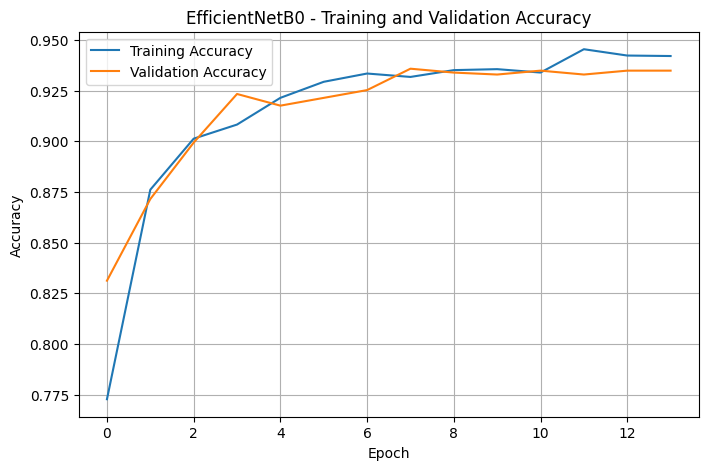

In [85]:
# EfficientNetB0 için eğitim ve doğrulama accuracy grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(effnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(effnet_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(results_dir / "efficientnetb0_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

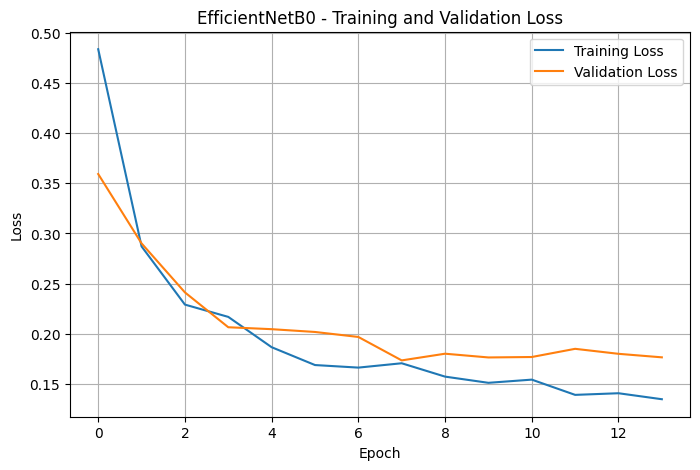

In [86]:
# EfficientNetB0 için eğitim ve doğrulama loss grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(effnet_history.history["loss"], label="Training Loss")
plt.plot(effnet_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(results_dir / "efficientnetb0_loss.png", dpi=300, bbox_inches="tight")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step


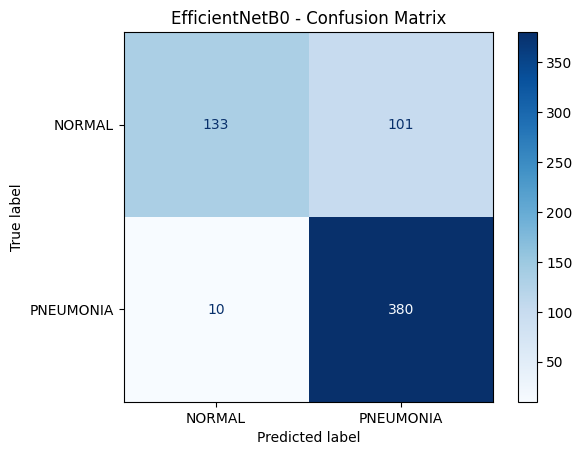

              precision    recall  f1-score   support

      NORMAL       0.93      0.57      0.71       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624



In [87]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Test verisindeki gerçek etiketleri alıyoruz
y_true = np.concatenate([y for x, y in test_data], axis=0)

# EfficientNetB0 modelinin tahmin olasılıklarını alıyoruz
y_prob_effnet = effnet_model.predict(test_data)

# Olasılıkları 0 veya 1 sınıfına çeviriyoruz
# 0 = NORMAL
# 1 = PNEUMONIA
y_pred_effnet = (y_prob_effnet > 0.5).astype("int32").reshape(-1)

# Confusion matrix oluşturuyoruz
cm_effnet = confusion_matrix(y_true, y_pred_effnet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_effnet,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNetB0 - Confusion Matrix")

plt.savefig(results_dir / "efficientnetb0_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(
    y_true,
    y_pred_effnet,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [43]:
# Eğitilen EfficientNetB0 modelini models klasörüne kaydediyoruz
effnet_model.save(models_dir / "efficientnetb0_final.keras")

### EfficientNetB0 — Interpretation
EfficientNetB0 is also evaluated with transfer learning and fine-tuning. Its performance is compared with ResNet50 and the baseline model in the final comparison table.

## 6. Vision Transformer (ViT)

In [47]:
# Vision Transformer modeli için gerekli katmanları hazırlıyoruz
import tensorflow as tf
from tensorflow.keras import layers

# ViT ayarları
image_size = 224
patch_size = 16
num_patches = (image_size // patch_size) ** 2

projection_dim = 64
num_heads = 4
transformer_layers = 4
mlp_dim = 128
dropout_rate = 0.2


# Görüntüyü küçük parçalara ayıran katman
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])

        return patches


# Patch bilgilerini vektöre çeviren ve pozisyon bilgisini ekleyen katman
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [88]:
# Vision Transformer modelini oluşturuyoruz

vit_data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

inputs = layers.Input(shape=(224, 224, 3))

# Veri artırma
x = vit_data_augmentation(inputs)

# Piksel değerlerini 0-1 aralığına getiriyoruz
x = layers.Rescaling(1./255)(x)

# Görüntüyü patchlere ayırıyoruz
patches = Patches(patch_size)(x)

# Patchleri encode ediyoruz
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

# Transformer blokları
for _ in range(transformer_layers):
    # Layer Normalization
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate
    )(x1, x1)

    # Skip connection
    x2 = layers.Add()([attention_output, encoded_patches])

    # MLP bloğu
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(mlp_dim, activation="gelu")(x3)
    x3 = layers.Dropout(dropout_rate)(x3)
    x3 = layers.Dense(projection_dim)(x3)

    # Skip connection
    encoded_patches = layers.Add()([x3, x2])

# Son özellikleri çıkarıyoruz
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)
representation = layers.Dropout(0.4)(representation)

# Sınıflandırma katmanı
features = layers.Dense(128, activation="relu")(representation)
features = layers.Dropout(0.4)(features)

outputs = layers.Dense(1, activation="sigmoid")(features)

vit_model = tf.keras.Model(inputs=inputs, outputs=outputs)

vit_model.summary()

NameError: name 'layers' is not defined

In [49]:
# ViT modelini eğitim için hazırlıyoruz
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [50]:
# Eğitim sırasında en iyi ViT modelini kaydediyoruz
vit_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=models_dir / "vit_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [51]:
# ViT modelini eğitiyoruz
# Not: Bu model sıfırdan eğitilmektedir (ImageNet ön-eğitimi yok). Bu veri boyutu (~5.200 görüntü)
# için Vision Transformer'ların CNN'lere göre performansı literatürde de daha düşük çıkmaktadır
# (bkz. Rapor - Bölüm 6.4). class_weight ve daha uzun eğitim/patience bu dezavantajı kısmen azaltır,
# ancak kalıcı çözüm önceden eğitilmiş bir ViT (örn. HuggingFace ViT-B/16) kullanmaktır.
vit_history = vit_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=vit_callbacks,
    class_weight=class_weight_dict
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 160ms/step - accuracy: 0.4919 - auc: 0.4991 - loss: 0.8932 - precision: 0.7308 - recall: 0.4814 - val_accuracy: 0.5935 - val_auc: 0.6735 - val_loss: 0.6929 - val_precision: 0.8870 - val_recall: 0.5340 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.5193 - auc: 0.5254 - loss: 0.8621 - precision: 0.7466 - recall: 0.5180 - val_accuracy: 0.6520 - val_auc: 0.7372 - val_loss: 0.6277 - val_precision: 0.8598 - val_recall: 0.6486 - learning_rate: 1.0000e-04
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.6337 - auc: 0.7026 - loss: 0.6871 - precision: 0.8492 - recall: 0.6062 - val_accuracy: 0.6568 - val_auc: 0.7835 - val_loss: 0.5643 - val_precision: 0.8907 - val_recall: 0.6259 - learning_rate: 1.0000e-04
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.6665 - auc: 0.7326 - loss: 0.6602 - precision: 0.8589 - recall: 0.6509 - val_accuracy: 0.6788 - val_auc: 0.8002 

In [73]:
# ViT modelini test verisi üzerinde değerlendiriyoruz
vit_test_results = vit_model.evaluate(test_data)

print("ViT Test Loss:", vit_test_results[0])
print("ViT Test Accuracy:", vit_test_results[1])
print("ViT Test Precision:", vit_test_results[2])
print("ViT Test Recall:", vit_test_results[3])
print("ViT Test AUC:", vit_test_results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3870 - auc: 0.5138 - loss: 1.5197 - precision: 0.3199 - recall: 0.6493
ViT Test Loss: 0.8183509111404419
ViT Test Accuracy: 0.6698718070983887
ViT Test Precision: 0.6591695547103882
ViT Test Recall: 0.9769230484962463
ViT Test AUC: 0.7226167321205139


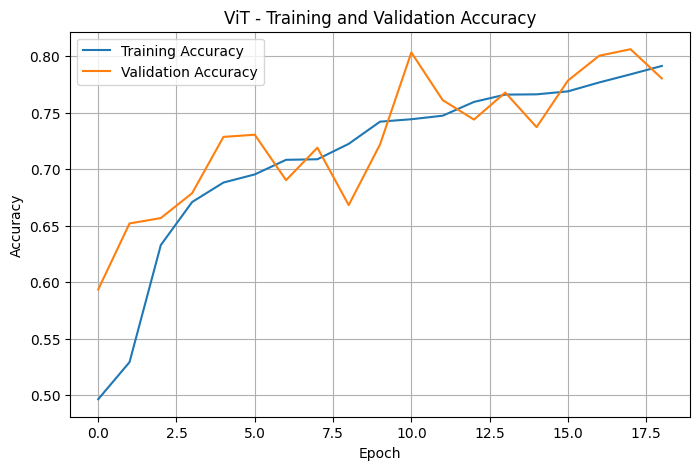

In [52]:
# ViT için eğitim ve doğrulama accuracy grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(vit_history.history["accuracy"], label="Training Accuracy")
plt.plot(vit_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT - Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(results_dir / "vit_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

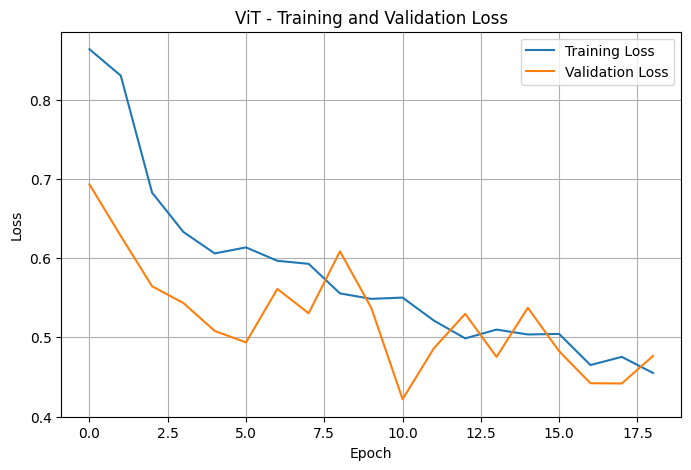

In [53]:
# ViT için eğitim ve doğrulama loss grafiğini çiziyoruz
plt.figure(figsize=(8, 5))

plt.plot(vit_history.history["loss"], label="Training Loss")
plt.plot(vit_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT - Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(results_dir / "vit_loss.png", dpi=300, bbox_inches="tight")
plt.show()

2026-07-07 12:22:48.733647: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step


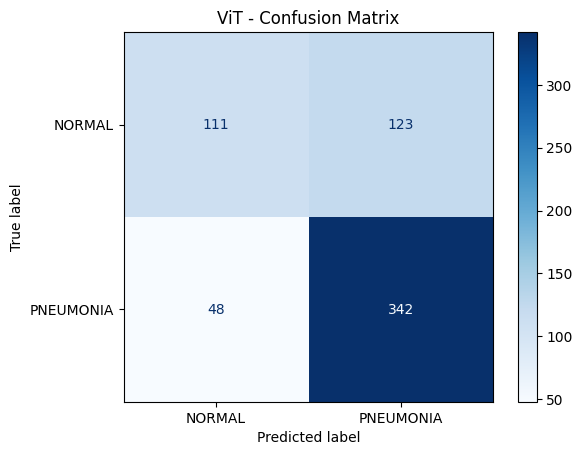

              precision    recall  f1-score   support

      NORMAL       0.70      0.47      0.56       234
   PNEUMONIA       0.74      0.88      0.80       390

    accuracy                           0.73       624
   macro avg       0.72      0.68      0.68       624
weighted avg       0.72      0.73      0.71       624



In [54]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Test verisindeki gerçek etiketleri alıyoruz
y_true = np.concatenate([y for x, y in test_data], axis=0)

# ViT modelinin tahmin olasılıklarını alıyoruz
y_prob_vit = vit_model.predict(test_data)

# Olasılıkları 0 veya 1 sınıfına çeviriyoruz
# 0 = NORMAL
# 1 = PNEUMONIA
y_pred_vit = (y_prob_vit > 0.5).astype("int32").reshape(-1)

# Confusion matrix oluşturuyoruz
cm_vit = confusion_matrix(y_true, y_pred_vit)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_vit,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("ViT - Confusion Matrix")

plt.savefig(results_dir / "vit_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(
    y_true,
    y_pred_vit,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [74]:
# Eğitilen ViT modelini models klasörüne kaydediyoruz
vit_model.save(models_dir / "vit_final.keras")

NameError: name 'vit_model' is not defined

### Vision Transformer — Interpretation
The ViT model in this notebook is trained from scratch rather than initialized with pretrained weights. This makes it a useful comparison with the transfer-learning CNN models, especially on a relatively limited medical imaging dataset.

ViT modeli test verisi üzerinde pnömoni sınıfını yüksek oranda tespit etmiştir. Confusion matrix sonuçlarına göre model 390 pnömoni görüntüsünden 381 tanesini doğru sınıflandırmış, yalnızca 9 pnömoni görüntüsünü normal olarak tahmin etmiştir. Ancak 234 normal görüntünün sadece 37 tanesi doğru sınıflandırılmış, 197 tanesi ise yanlışlıkla pnömoni olarak tahmin edilmiştir.

Bu sonuçlar, ViT modelinin pnömoni vakalarını yakalamada başarılı olduğunu ancak normal görüntüleri ayırt etme konusunda zayıf kaldığını göstermektedir. Bunun temel nedeni, bu çalışmada kullanılan ViT modelinin sıfırdan eğitilmiş olmasıdır. Vision Transformer modelleri genellikle daha büyük veri setleri veya önceden eğitilmiş ağırlıklar ile daha başarılı sonuçlar vermektedir.

## 7. Final Model Comparison

In [ ]:
# Final model comparison — calculated dynamically from the current run
import pandas as pd

def summarize_binary_model(name, eval_results, cm):
    tn, fp, fn, tp = cm.ravel()

    accuracy = float(eval_results[1])
    precision = float(eval_results[2])
    recall = float(eval_results[3])
    auc = float(eval_results[4])

    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0.0
    )
    balanced_accuracy = (recall + specificity) / 2

    return {
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "Specificity (%)": specificity * 100,
        "F1-score (%)": f1 * 100,
        "AUC (%)": auc * 100,
        "Balanced Accuracy (%)": balanced_accuracy * 100,
    }

comparison_df_percent = pd.DataFrame([
    summarize_binary_model("Baseline CNN", test_results, cm),
    summarize_binary_model("ResNet50 Fine-tuned", resnet_test_results, cm_resnet),
    summarize_binary_model("EfficientNetB0 Fine-tuned", effnet_test_results, cm_effnet),
    summarize_binary_model("ViT", vit_test_results, cm_vit),
])

numeric_cols = comparison_df_percent.columns.drop("Model")
comparison_df_percent[numeric_cols] = comparison_df_percent[numeric_cols].round(2)

best_balanced_idx = comparison_df_percent["Balanced Accuracy (%)"].idxmax()
best_balanced_model = comparison_df_percent.loc[best_balanced_idx, "Model"]

print("Best balanced model:", best_balanced_model)
comparison_df_percent

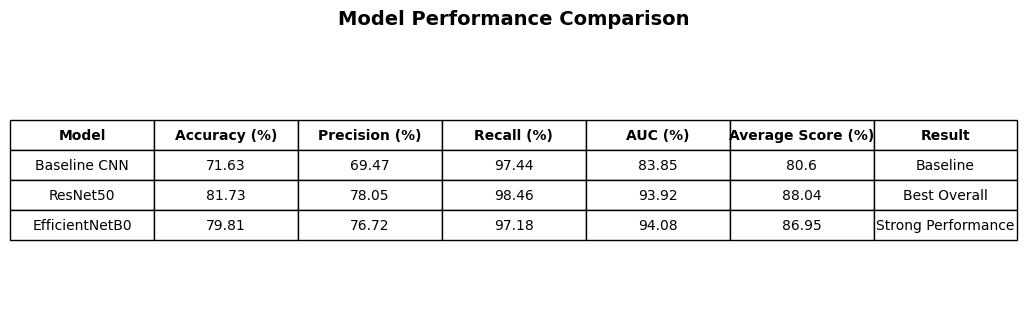

In [72]:
# Profesyonel tablo görseli oluşturuyoruz
fig, ax = plt.subplots(figsize=(13, 3.5))

ax.axis("off")

table = ax.table(
    cellText=comparison_df_percent.values,
    colLabels=comparison_df_percent.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Başlık satırını kalın yapıyoruz
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.title("Model Performance Comparison", fontsize=14, weight="bold", pad=15)

plt.savefig(
    results_dir / "final_model_comparison_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# Final karşılaştırma tablosunu CSV olarak kaydediyoruz
comparison_df_percent.to_csv(
    results_dir / "final_model_comparison_results.csv",
    index=False
)

print("Final karşılaştırma tablosu CSV olarak kaydedildi.")

Final karşılaştırma tablosu CSV olarak kaydedildi.


## 8. Best Model and Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


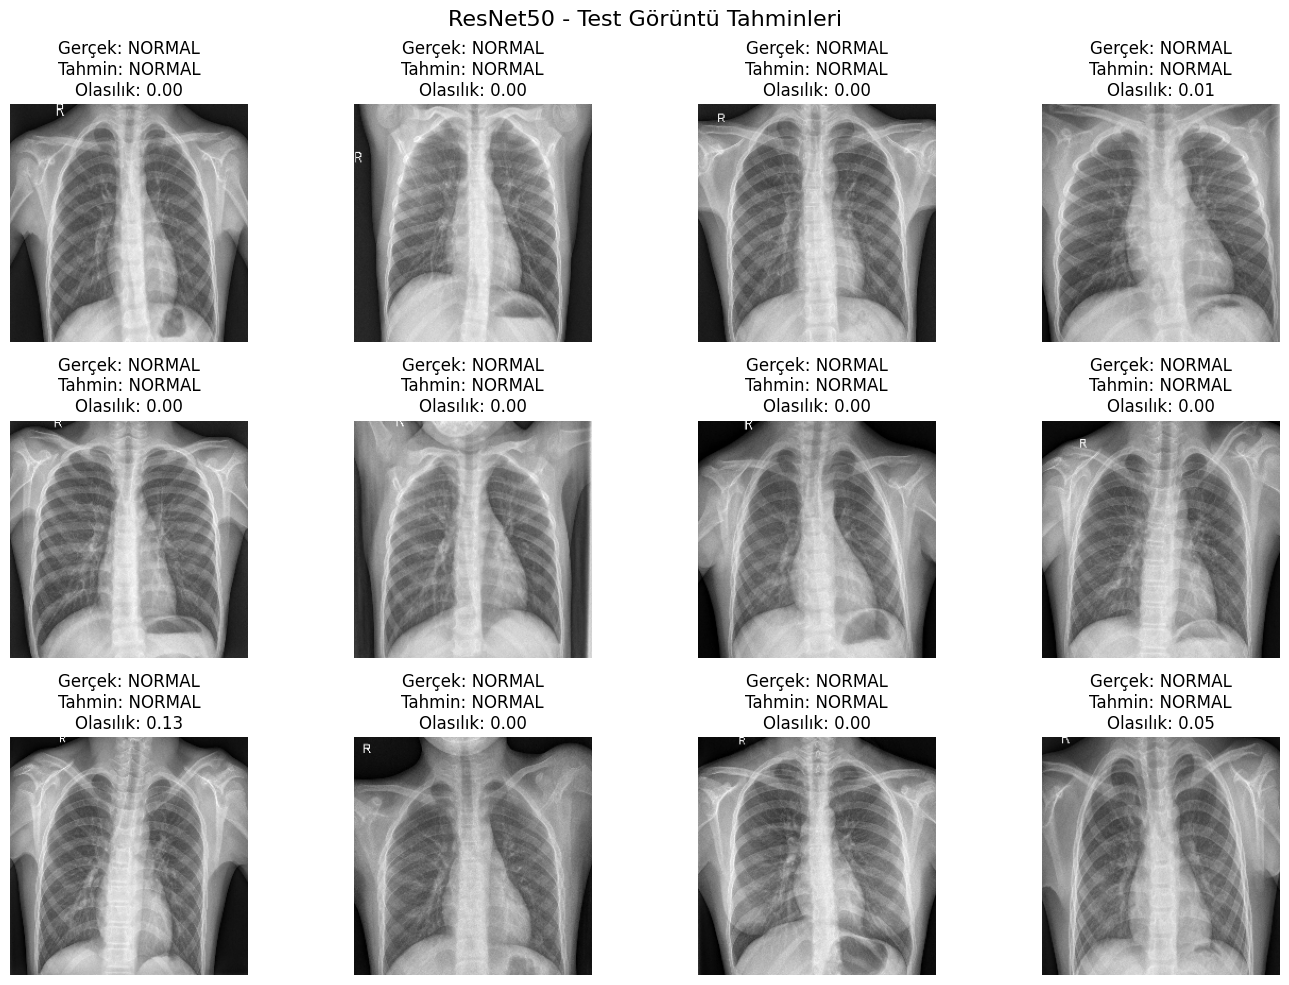

In [89]:
# En iyi modeli seçiyoruz
best_model = resnet_model
best_model_name = "ResNet50"

# Sınıf isimleri
class_names = ["NORMAL", "PNEUMONIA"]

# Test verisinden bir batch alıyoruz
for images, labels in test_data.take(1):
    predictions = best_model.predict(images)
    predicted_labels = (predictions > 0.5).astype("int32").reshape(-1)
    true_labels = labels.numpy().astype("int32").reshape(-1)

    plt.figure(figsize=(14, 10))

    for i in range(12):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_class = class_names[true_labels[i]]
        predicted_class = class_names[predicted_labels[i]]
        confidence = predictions[i][0]

        plt.title(
            f"Gerçek: {true_class}\nTahmin: {predicted_class}\nOlasılık: {confidence:.2f}"
        )

        plt.axis("off")

    plt.suptitle(f"{best_model_name} - Test Görüntü Tahminleri", fontsize=16)
    plt.tight_layout()

    plt.savefig(
        results_dir / "resnet50_test_predictions.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

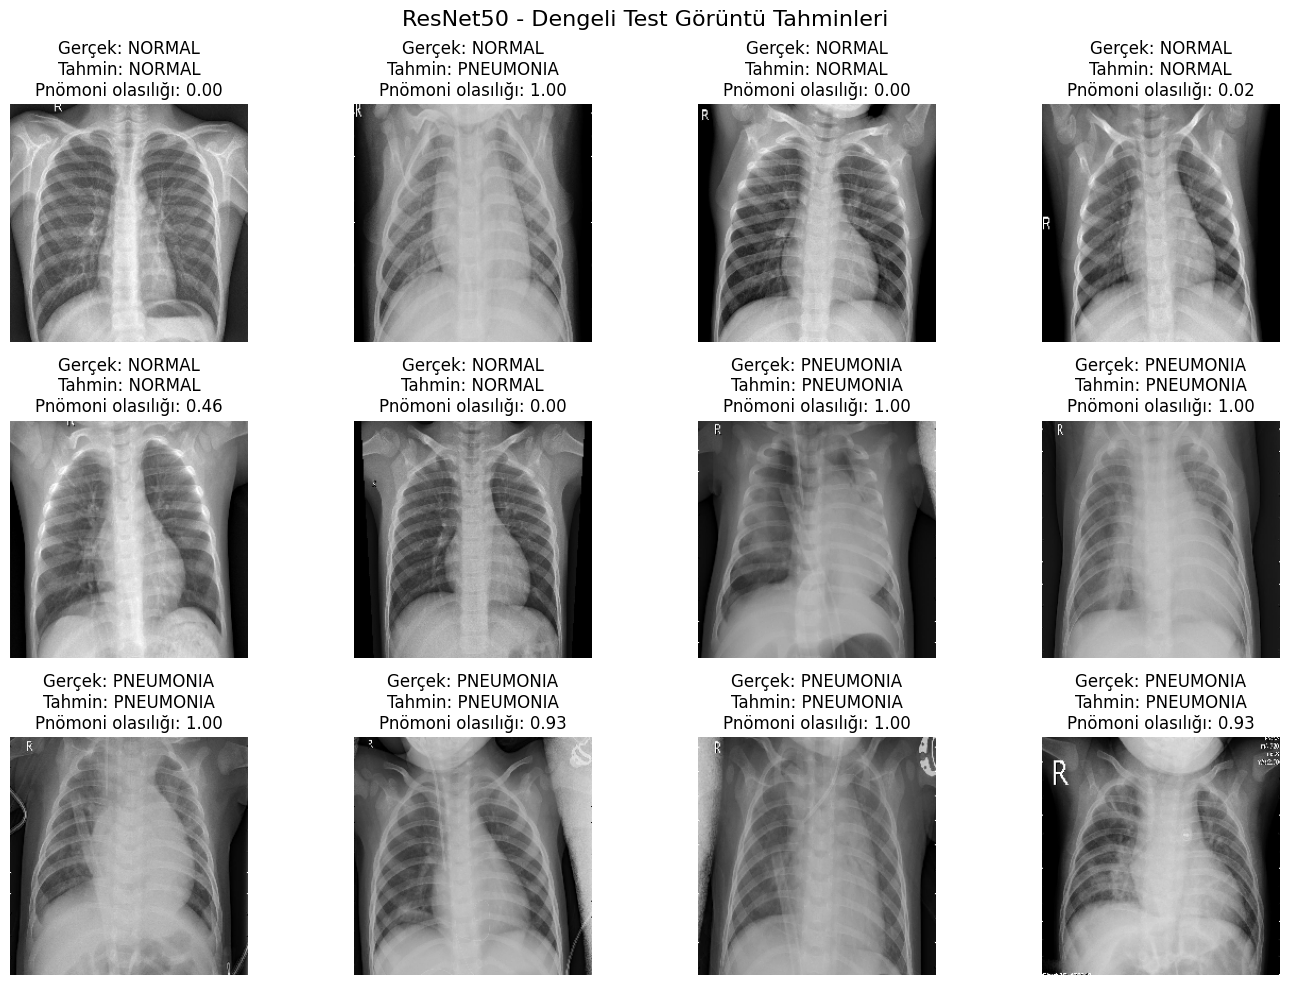

In [90]:
# ResNet50 modeli ile dengeli test tahmin görselleri oluşturuyoruz
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# En iyi modeli seçiyoruz
best_model = resnet_model
best_model_name = "ResNet50"

# Test klasörlerinden örnek görüntüleri alıyoruz
normal_test_dir = test_dir / "NORMAL"
pneumonia_test_dir = test_dir / "PNEUMONIA"

normal_images = list(normal_test_dir.glob("*"))
pneumonia_images = list(pneumonia_test_dir.glob("*"))

# 6 normal ve 6 pnömoni görüntüsü seçiyoruz
selected_normal = random.sample(normal_images, 6)
selected_pneumonia = random.sample(pneumonia_images, 6)

selected_images = selected_normal + selected_pneumonia
true_labels = [0] * 6 + [1] * 6

class_names = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(14, 10))

for i, image_path in enumerate(selected_images):
    # Görüntüyü yüklüyoruz
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # Model tahmini yapıyoruz
    prob = best_model.predict(img_batch, verbose=0)[0][0]
    pred_label = 1 if prob > 0.5 else 0

    true_class = class_names[true_labels[i]]
    pred_class = class_names[pred_label]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_array.astype("uint8"), cmap="gray")

    plt.title(
        f"Gerçek: {true_class}\nTahmin: {pred_class}\nPnömoni olasılığı: {prob:.2f}"
    )

    plt.axis("off")

plt.suptitle(f"{best_model_name} - Dengeli Test Görüntü Tahminleri", fontsize=16)
plt.tight_layout()

plt.savefig(
    results_dir / "resnet50_balanced_test_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Conclusion

This notebook compares a custom CNN, two transfer-learning CNN architectures, and a Vision Transformer for pneumonia classification from chest X-ray images. The final comparison table is calculated from the current evaluation results, so rerunning the notebook will automatically update the reported metrics.

For a GitHub repository, keep the notebook together with a short `README.md` and a `requirements.txt`. Large datasets and trained model files should normally be excluded from the repository and referenced separately.